# **RFscorer Tutorial: Advanced (English): Aggregating Frequency by Number of Days Viewed**

This notebook demonstrates how to aggregate frequency by the **number of days an item was viewed** instead of the **number of views**, in order to cap the upper bound of frequency.

Normally, frequency counts the **number of times** a user viewed an item within the observation window. However, this lets frequency grow extremely large for users who view an item many times in a short period, producing a long-tailed distribution.
By counting **multiple views on the same day (same time step) as a single occurrence**, we convert frequency into the **number of days an item was viewed**. This caps the upper bound of frequency at the length of the observation window (`observation_days`) and stabilizes its value range.

You will learn the following workflow.

1. **Convert frequency from "number of views" to "number of days viewed"** by dropping duplicate (user, item, date) rows — the key step specific to this tutorial
2. Split the data with `split_by_date()`
3. Build models with `fit()` and visualize (set `frequency_limit` to the number of observation days)
4. Compute recommendation scores with `transform()` and compare accuracy across models

The workflow is identical to the Practical tutorial (`tutorial_practical_en.ipynb`); only the deduplication in step 1 is added.

**Intended scenarios**
- Data where count-based frequency becomes extremely large because the same item is viewed many times a day
- Cases where you want to cap frequency by the observation window (in days) and stabilize its range
- Cases where "how many days viewed" represents preference better than "how many times viewed"

When using Google Colab, the following setup is required.
- Install `rfscorer`
```python
!pip install rfscorer
```
- Mount Google Drive (if reading/writing files)
```python
from google.colab import drive
drive.mount("/content/drive")
```

---
## **Data Loading and Preprocessing**
Load a public dataset hosted on GitHub via its URL, then split the data in two stages.

- **Time-based split**: divide at a reference date so that past data is used for training and the most recent period for evaluation (reproducing the real-world scenario of predicting the future from past data)
- **Period split**: divide each portion into observation data and ground-truth data

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

In [2]:
# `access_log.csv` is from ohmsha/PyOptBook (MIT License)
# https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
# Rename to the default column names of RecencyFrequencyScorer
# (user_col="user", item_col="item", time_col="datetime")
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
print("datetime num:", len(sorted(df.datetime.unique())))
print("datetime:", sorted(df.datetime.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611
datetime num: 8
datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08']


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


In [3]:
# --- Key point of this tutorial -----------------------------------
# Aggregate frequency by "number of days viewed" instead of "number of views".
# Dropping duplicate (user, item, datetime) rows collapses multiple
# views on the same day into a single occurrence.
# This caps the upper bound of frequency at the number of observation days
# (observation_days) and stabilizes its value range.
# The way split_by_date / fit / transform are called is unchanged from
# the usual (count-based) case.
# ------------------------------------------------------------------
print("before (count-based):", len(df))
df = df.drop_duplicates(subset=["user", "item", "datetime"])
print("after  (days-based) :", len(df))
df.head()

before (count-based): 325908
after  (days-based) : 243064


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
4,4,764638,2015-07-04
6,4,492434,2015-07-04


In [4]:
# Split into training and test data by time (assuming production: predict the future from past data)
# df_train: data available at training time (up to 2015-07-07)
# df_test : for evaluation (prediction target date 2015-07-08)
target_date = "2015-07-07"
gt_date = "2015-07-08"
df_train = df[df.datetime <= target_date]
df_test = df[df.datetime <= gt_date]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 213413 / user num: 28605
test  record num:  243064 / user num:  31443


In [5]:
# split_by_date() divides training/test data into observation data and ground-truth data
# Observation data (6 days up to the reference date): period used to compute recency and frequency
# Ground-truth data (1 day after the reference date): period recording target events (re-view, purchase, CV, etc.)
fit_date = "2015-07-06"  # reference date for training
df_train_obs, df_train_gt = split_by_date(df_train, fit_date, observation_days=6, gt_days=1)
df_test_obs, df_test_gt = split_by_date(df_test, target_date, observation_days=6, gt_days=1)

print("--- train ---")
print("obs/datetime num:", len(sorted(df_train_obs.datetime.unique())))
print(sorted(df_train_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_train_gt.datetime.unique())))
print(sorted(df_train_gt.datetime.unique()))

print("--- test ---")
print("obs/datetime num:", len(sorted(df_test_obs.datetime.unique())))
print(sorted(df_test_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_test_gt.datetime.unique())))
print(sorted(df_test_gt.datetime.unique()))

--- train ---
obs/datetime num: 6
['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06']
gt/datetime num: 1
['2015-07-07']
--- test ---
obs/datetime num: 6
['2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07']
gt/datetime num: 1
['2015-07-08']


---
## **Model Building and Visualization**

Estimate the empirical product-choice probability from the training data (`fit`), then build 4 optimization models.
Because frequency is aggregated by number of days viewed, its upper bound equals the number of observation days (`observation_days=6`).
Accordingly, set `frequency_limit` to `6`.

| Model | Type | Constraints |
|-------|------|-------------|
| `emp` | Empirical (2D) | none |
| `er` / `ef` | Empirical (1D) | none |
| `mono` | Optimization (2D) | monotonicity only |
| `mrc` | Optimization (2D) | monotonicity + Recency convexity |
| `mfc` | Optimization (2D) | monotonicity + Frequency concavity |
| `mcc` | Optimization (2D) | monotonicity + Recency convexity + Frequency concavity |

In [6]:
# No arguments needed since the default column names
# (user_col="user", item_col="item", time_col="datetime") are used
scorer = RecencyFrequencyScorer()

In [7]:
# === fit ===
# fit_date    : 2015-07-06
# target_date : 2015-07-07
# gt_date     : 2015-07-08
#                    f t g
#                    ^ ^ ^
# 2015-07-01 2 3 4 5 6 7 8
# test       * * * * * * @
# train    * * * * * * @
# *: observation (observation_days=6),  @: ground truth (gt_days=1)
# frequency_limit=6: frequency (days viewed) is capped at the number of observation days (6), so set 6
scorer.fit(df_train_obs, df_train_gt, ref=fit_date, recency_limit=6, frequency_limit=6)

scorer.show()  # show data statistics, correlation, and the empirical product-choice probability table

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 187995 rows,  gt 25418 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180840  (before → after applying limits)
  target events    : 1597 → 1597  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 6
  frequency_limit  : 6

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.9000  (p=0.0374,  n=5,  weighted ρ:  0.9954)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9887
    r= 2:   0.9049
    r= 3:   1.0000
    r= 4:   1.0000
    r= 5:   1.0000
    r= 6:  nan
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f= 1:  -1.0000
  

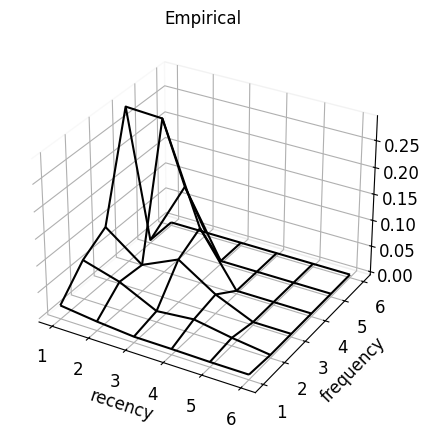

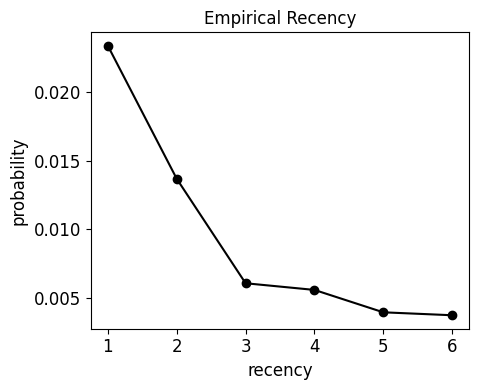

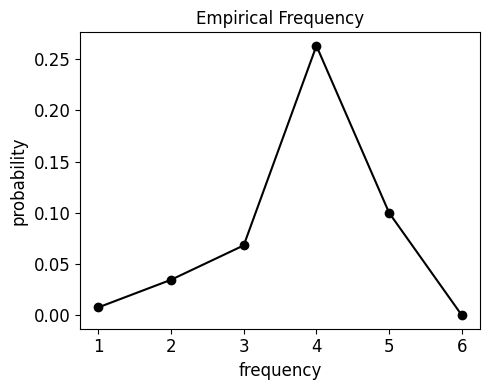

In [8]:
# emp: empirical product-choice probability (raw 2D table; contains sampling noise)
# er / ef: 1D empirical product-choice probability for recency / frequency
# The x-axis (frequency) of ef is "days viewed" and extends only up to the number of observation days (6)
fig_emp = scorer.plot_probability_surface(kind="emp")
fig_er = scorer.plot_marginal_probability(kind="er")
fig_ef = scorer.plot_marginal_probability(kind="ef")

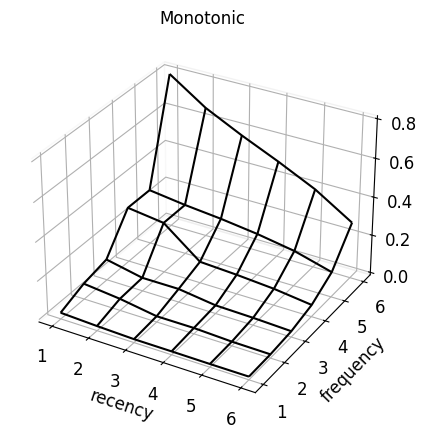

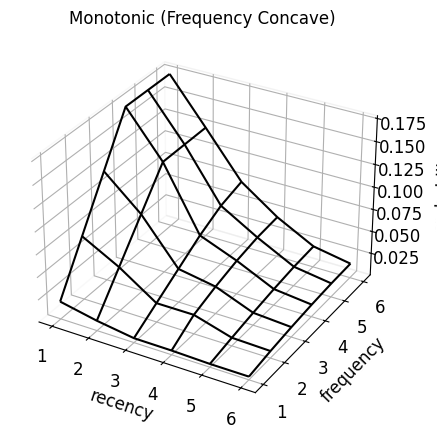

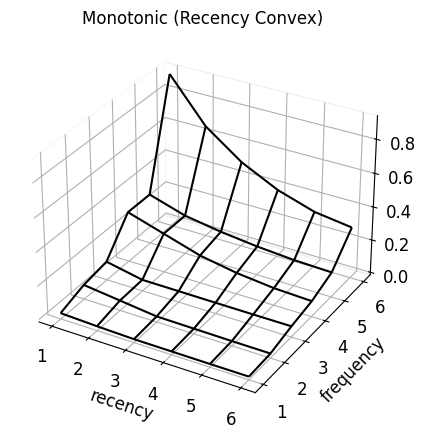

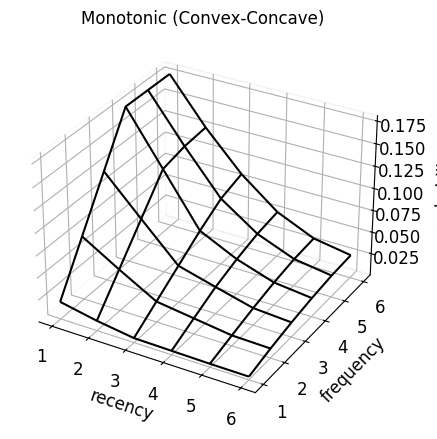

In [9]:
# 2D optimization models: mono(monotonicity only) / mrc(+Recency convexity) / mfc(+Frequency concavity) / mcc(+both)
scorer.optimize(kind="mono")
scorer.optimize(kind="mrc")
scorer.optimize(kind="mfc")
scorer.optimize(kind="mcc")

fig_mono = scorer.plot_probability_surface(kind="mono")
fig_mfc = scorer.plot_probability_surface(kind="mfc")
fig_mrc = scorer.plot_probability_surface(kind="mrc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

---
## **Computing Recommendation Scores and Comparing Model Accuracy**

Compute recommendation scores (product-choice probabilities) for each model with `transform()`, then match them against the ground-truth data (`df_test_gt`) and compare accuracy with `evaluate()`.
We check which model is most accurate when frequency is aggregated by number of days viewed.

In [10]:
# Attach each model's product-choice probability (recommendation score) and rank to the test observation data
# ref=target_date: compute recency relative to the evaluation point ("today" in production)
kinds = ["emp", "er", "ef", "mono", "mrc", "mfc", "mcc"]
kind2df_rec = {kind: scorer.transform(df_test_obs, target_date, kind=kind) for kind in kinds}
kind2df_rec["mcc"].head()

,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003733,1
72,100,185046,6,1,0.003733,2
73,100,1002465,6,1,0.003733,3
40705,100003,675829,4,1,0.004641,1
40706,100003,979166,4,1,0.004641,2


In [11]:
# Match each model's recommendations against the ground-truth data (df_test_gt) and compare by precision@1
# Identify the most accurate model when frequency is aggregated by "days viewed"
Rows = []
for kind, df_rec in kind2df_rec.items():
    top = scorer.evaluate(df_rec, df_test_gt, order=1).iloc[0]
    Rows.append((kind, top["precision"], top["recall"], top["f1"]))
df_eval = pd.DataFrame(Rows, columns=["kind", "precision", "recall", "f1"])
df_eval.sort_values("precision", ascending=False)

,kind,precision,recall,f1
6,mcc,0.016627,0.014232,0.015337
4,mrc,0.016548,0.014165,0.015264
1,er,0.016470,0.014097,0.015191
3,mono,0.016430,0.014064,0.015155
5,mfc,0.016430,0.014064,0.015155
0,emp,0.016351,0.013996,0.015082
2,ef,0.015406,0.013187,0.014210
